In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt

from core_ntsa.mf_dfa import (
    mf_dfa,
    plot_scaling,
    plot_hq,
    plot_tau,
    plot_singularity,
    plot_summary
)

In [2]:
def generate_monofractal_series(H, N=65536):
    """
    Sinh chuỗi Fractional Gaussian Noise (fGn) với chỉ số Hurst cho trước.
    Sử dụng phương pháp lọc phổ Fourier (Fourier Filtering Method).
    
    Parameters:
        H (float): Chỉ số Hurst (0 < H < 1).
        N (int): Độ dài chuỗi dữ liệu (Mặc định 65536).
        
    Returns:
        numpy.ndarray: Chuỗi thời gian fGn đã được chuẩn hóa (mean=0, std=1).
    """
    # 1. Khởi tạo nhiễu trắng ngẫu nhiên chuẩn
    rng = np.random.default_rng()
    white_noise = rng.standard_normal(N)
    
    # 2. Chuyển sang miền tần số bằng FFT
    X_f = np.fft.rfft(white_noise)
    
    # 3. Tạo trục tần số và tránh lỗi chia cho 0 tại f=0
    freqs = np.fft.rfftfreq(N)
    freqs[0] = 1e-10 
    
    # 4. Áp dụng bộ lọc phân dạng
    # Mật độ phổ công suất của fGn tỷ lệ với f^(1 - 2H)
    # Do đó, biên độ phổ tỷ lệ với f^(0.5 - H)
    filter_amplitude = freqs ** (0.5 - H)
    filter_amplitude[0] = 0  # Đảm bảo kỳ vọng (mean) bằng 0
    
    X_filtered = X_f * filter_amplitude
    
    # 5. Biến đổi ngược (IFFT) về lại miền thời gian
    fgn = np.fft.irfft(X_filtered, n=N)
    
    # 6. Chuẩn hóa chuỗi (Z-score normalization)
    fgn_normalized = (fgn - np.mean(fgn)) / np.std(fgn)
    
    return fgn_normalized

### Ý nghĩa cốt lõi của việc thiết lập dữ liệu kiểm thử (Mục 3.1)

Việc sử dụng phương pháp biến đổi Fourier để sinh dữ liệu giả lập (Data Generation) mang ý nghĩa thiết lập một **môi trường đối chứng (baseline test)** hoàn hảo cho thuật toán MF-DFA. Việc setup này phục vụ 3 mục đích kỹ thuật tối quan trọng:

**1. Kiểm soát tuyệt đối "Trí nhớ" của hệ thống**
Phương pháp Fourier cho phép chủ động can thiệp vào phổ năng lượng, từ đó "lập trình" mức độ tương quan dài hạn của dữ liệu thông qua chỉ số $H$ [1]. Hệ thống test được chia thành 3 kịch bản rõ ràng:
*   **$H = 0.25$:** Tương quan nghịch (các dao động có xu hướng đảo chiều liên tục).
*   **$H = 0.50$:** Nhiễu trắng (hoàn toàn ngẫu nhiên, không có trí nhớ).
*   **$H = 0.75$:** Tương quan thuận dài hạn (đặc tính giống với nhịp tim sinh lý khỏe mạnh) [1].

**2. Bài test "Chống ảo giác" (Ngăn chặn False Positive)**
Về mặt toán học, các chuỗi được tạo ra đảm bảo 100% là **đơn phân dạng (monofractal)**. Do đó, lý thuyết ép buộc chỉ số $h(q)$ không được phép thay đổi theo lăng kính $q$, tức là $h(q) = H$ [1, 2]. Bài test này dùng để chứng minh thuật toán MF-DFA không bị "ảo giác", tức là không nhận diện nhầm một chuỗi cấu trúc đơn giản thành một chuỗi đa phân dạng phức tạp.

**3. Thiết lập "Thước đo sai số" cho dữ liệu thực tế (PPG)**
Dù dữ liệu sinh ra là đơn phân dạng hoàn hảo, đồ thị $h(q)$ thu được vẫn có sự dao động nhẹ (slight $q$ dependence) do giới hạn thống kê của chuỗi dữ liệu hữu hạn [3]. Sự dao động này cung cấp một **ngưỡng sai số tự nhiên**. Khi áp dụng vào phân tích PPG thực tế, đây chính là "hệ quy chiếu" giúp ta không vội vã kết luận tín hiệu có tính đa phân dạng nếu độ cong của phổ chưa vượt qua mức sai số cơ sở này.

Đang khởi tạo dữ liệu fGn...
Đang xử lý tính toán MF-DFA...
Đang xuất đồ thị thực nghiệm...


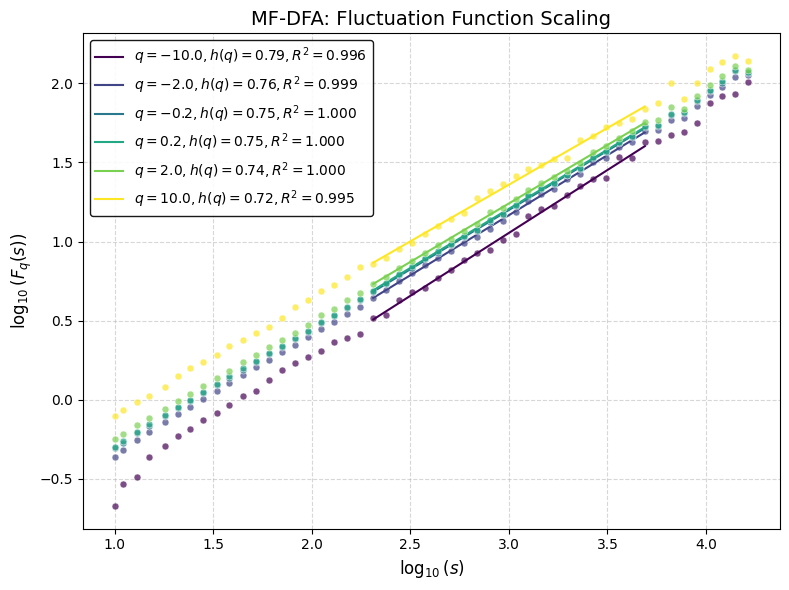

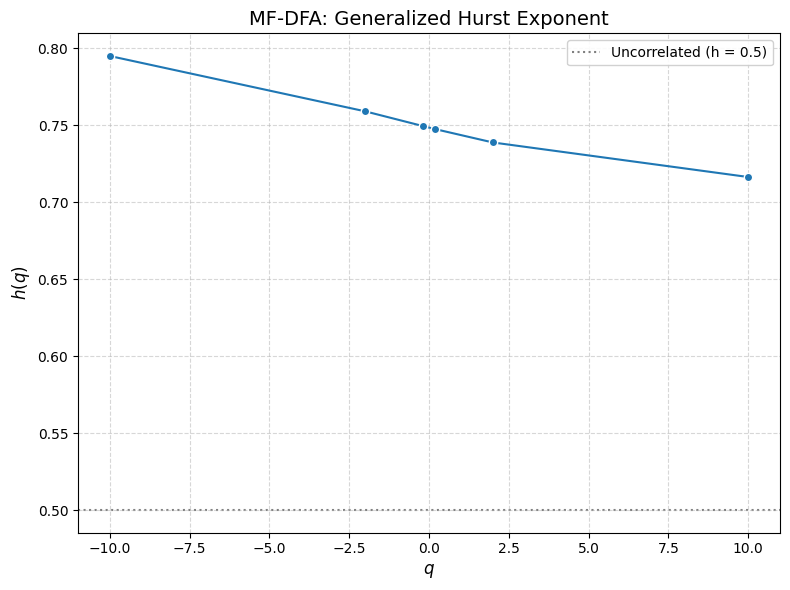

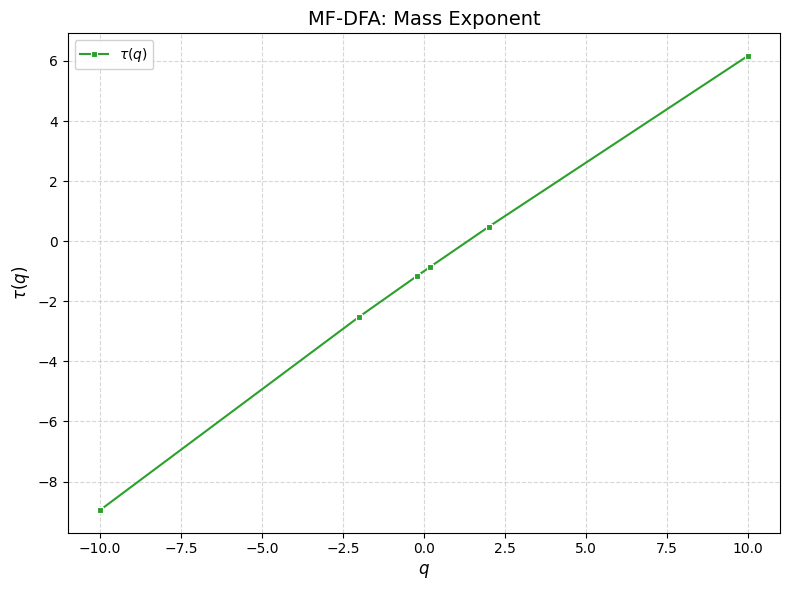

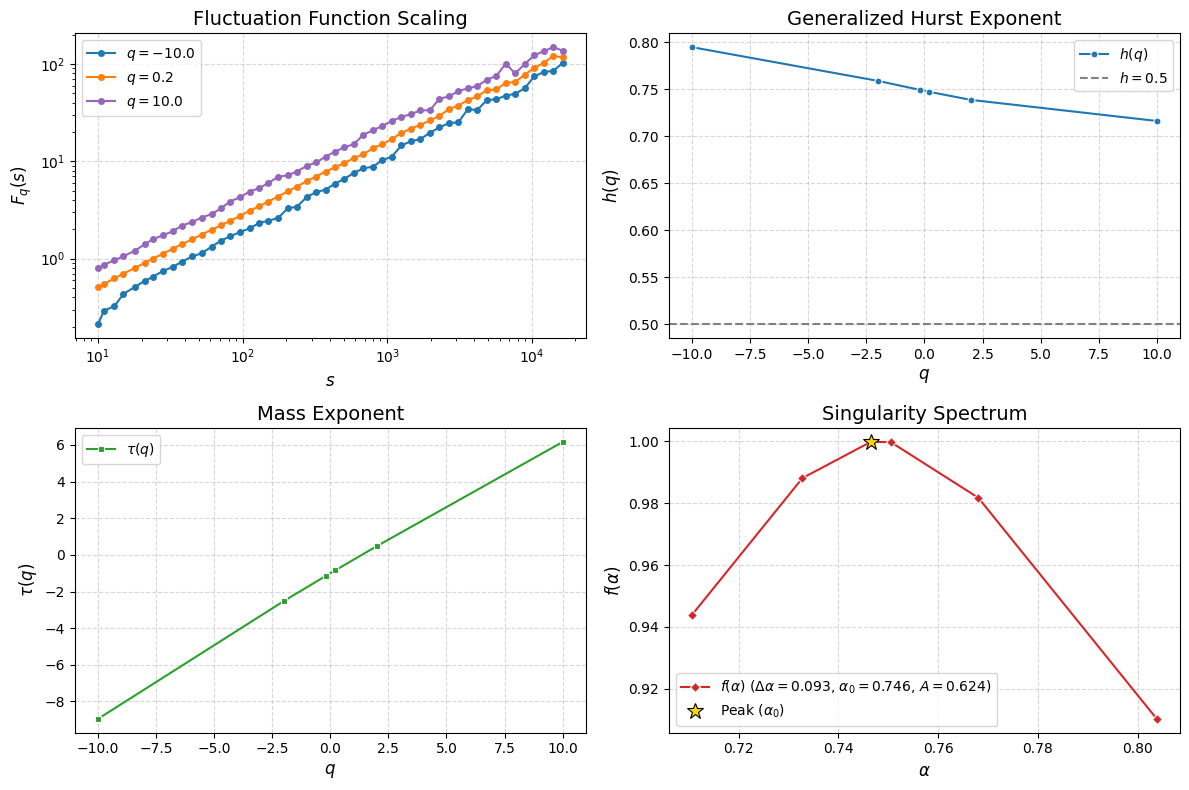

In [ ]:
N = 65536
m_order = 2  

# Lăng kính q và mảng s_array
q_values = np.array([-10, -2, -0.2, 0.2, 2, 10])
s_values = np.logspace(np.log10(10), np.log10(N/4), 50).astype(int)

# Tham số fit_range (200, 5000)
min_scale_val = 200
max_ratio_val = int(N / 5000)

print("Đang khởi tạo dữ liệu fGn...")

series_H075 = generate_monofractal_series(H=0.75, N=N)

# ---------------------------------------------------------
# 2. CHẠY PIPELINE MF-DFA (Tuân thủ đúng signature)
# ---------------------------------------------------------
print("Đang xử lý tính toán MF-DFA...")


results_H075 = mf_dfa(
    data=series_H075, 
    s_array=s_values, 
    q_array=q_values, 
    m=m_order, 
    min_scale=min_scale_val, 
    max_scale_ratio=max_ratio_val
)

# ---------------------------------------------------------
# 3. TRỰC QUAN HÓA KẾT QUẢ (Gọi từng result riêng biệt)
# ---------------------------------------------------------
print("Đang xuất đồ thị thực nghiệm...")

# a) Hàm thăng giáng F_q(s)
# Truyền use_raw=True để quan sát điểm gãy, truyền thêm tham số cho plt qua **kwargs nếu hàm của bạn hỗ trợ
plot_scaling(results_H075, q_values=q_values, use_raw=True, figsize=(8, 6))

# b) Số mũ Hurst tổng quát h(q)
# Do API chỉ nhận 1 result dict, đồ thị sẽ được tách riêng ra thay vì vẽ chồng
plot_hq(results_H075, show_error=False, figsize=(8, 6))

# c) Số mũ khối lượng tau(q)
plot_tau(results_H075, figsize=(8, 6))

# d) Bảng Dashboard (Chỉ test với 1 chuỗi)
plot_summary(results_H075, figsize=(12, 8))


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings


def generate_binomial_cascade(n_max=16, a=0.75):
    """
    Sinh chuỗi đa phân dạng nhị thức (Deterministic Binomial Cascade).
    N = 2^n_max. Mặc định n_max=16 (N=65536).
    """
    N = 2**n_max
    # Sử dụng bit_count() của Python >= 3.10 cho tốc độ tối đa
    n_ones = np.array([i.bit_count() for i in range(N)])
    
    # x_k = a^{n(k-1)} * (1-a)^{n_max - n(k-1)}
    x = (a ** n_ones) * ((1 - a) ** (n_max - n_ones))
    return x

def theoretical_multifractal_truth(q_array, a=0.75):
    """
    Tính toán chính xác các hàm số học lý thuyết (Ground Truth).
    """
    tau = np.zeros_like(q_array, dtype=float)
    alpha = np.zeros_like(q_array, dtype=float)
    f_alpha = np.zeros_like(q_array, dtype=float)
    hq = np.zeros_like(q_array, dtype=float)
    
    for i, q in enumerate(q_array):
        if np.isclose(q, 0.0):
            # Xử lý giới hạn khi q = 0
            tau[i] = -1.0
            alpha[i] = -(np.log(a) + np.log(1 - a)) / (2 * np.log(2))
            hq[i] = alpha[i]
            f_alpha[i] = 1.0 # f(alpha) tại đỉnh luôn = 1
        else:
            term = (a**q) + ((1 - a)**q)
            # tau(q)
            tau[i] = -np.log(term) / np.log(2)
            # alpha(q)
            numerator = (a**q * np.log(a)) + ((1 - a)**q * np.log(1 - a))
            alpha[i] = -(numerator / term) / np.log(2)
            # h(q) = (tau(q) + 1) / q
            hq[i] = (tau[i] + 1) / q
            # f(alpha) = q*alpha - tau
            f_alpha[i] = q * alpha[i] - tau[i]
            
    return hq, tau, alpha, f_alpha



### Phân tích Đặc tính Dữ liệu: Mô hình Đa phân dạng Nhị thức (Mục 3.2)

Khác với dữ liệu nhiễu ngẫu nhiên ở Mục 3.1, tập dữ liệu sinh ra từ Mô hình Nhị thức mang những đặc tính toán học hoàn toàn khác biệt, phục vụ mục đích "ép xung" thuật toán MF-DFA ở mức độ phức tạp cao nhất.

**1. Bản chất Tất định (Deterministic Multifractal)**
*   **Không có yếu tố ngẫu nhiên:** Chuỗi dữ liệu được tạo ra hoàn toàn bằng một quy luật toán học tĩnh (dựa trên số lượng bit `1` trong hệ nhị phân của vị trí index) với trọng số $a = 0.75$ [1]. 
*   **Cấu trúc phân tầng hoàn hảo:** Cơ chế nhân dồn các trọng số $a$ và $(1-a)$ tạo ra một chuỗi có sự đan xen liên tục giữa các đoạn dao động cực lớn và cực nhỏ theo một tỷ lệ vàng cố định [1].

**2. Sở hữu "Ground Truth" Toán học Tuyệt đối**
*   Điểm giá trị nhất của bộ dữ liệu này là **có thể tính toán chính xác bằng giải tích** phương trình của $\tau(q)$ và $h(q)$ mà không cần chạy bất kỳ thuật toán xấp xỉ nào [2, 3]. 
*   Đồ thị $h(q)$ lý thuyết là một đường cong phi tuyến trượt dốc mạnh [3]. Đây là "thước đo chuẩn mực" để vẽ đè lên kết quả chạy code của bạn nhằm đo lường sai số thuật toán [4].

**3. Khám phá Giới hạn Tiệm cận (Asymptotic Limits)**
Dữ liệu này bộc lộ rõ nhất ý nghĩa vật lý của lăng kính $q$:
*   **Tại vùng $q$ dương lớn ($q \to +\infty$):** Phổ $h(q)$ bị chi phối bởi các đoạn có thăng giáng lớn nhất trong chuỗi, tiệm cận về mốc $-\ln(a)/\ln(2)$ (với $a=0.75$, $h(+10) \approx 0.515$) [3, 5].
*   **Tại vùng $q$ âm lớn ($q \to -\infty$):** Phổ $h(q)$ bị chi phối bởi các đoạn có thăng giáng nhỏ nhất, tiệm cận về mốc $-\ln(1-a)/\ln(2)$ (với $a=0.75$, $h(-10) \approx 1.90$) [3, 5].

**4. Phép thử Năng lực Khử xu hướng (Detrending Test)**
*   Chính vì cấu trúc dữ liệu nhị thức rất phức tạp, nó được dùng để chứng minh sự ưu việt của các đa thức bậc cao. 
*   Khi chạy thử nghiệm, bạn sẽ thấy **MF-DFA4** (khử xu hướng bậc 4) sẽ bám sát đường cong lý thuyết tốt hơn so với **MF-DFA1** (khử xu hướng tuyến tính), đặc biệt là ở các vùng $q$ âm [5]. 

Đang chạy phân tích MF-DFA1 (m=1)...


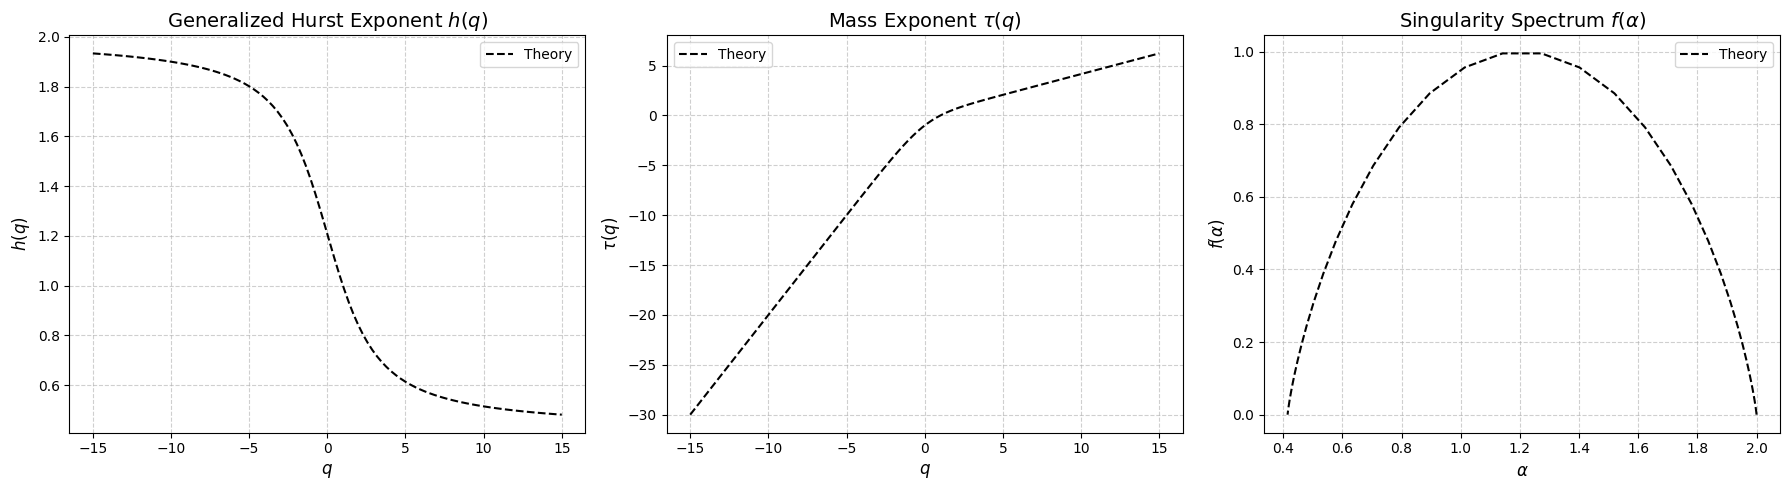

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Thông số chuỗi nhị thức
n_max = 13          # N = 8192
a_weight = 0.75     # Trọng số


# Cấu hình MF-DFA
q_scatter = np.array([-10, -2, -0.2, 0.2, 2, 10]) # Dùng cho F_q(s)
q_dense = np.linspace(-15, 15, 31)                # Dùng cho h(q), tau(q), f(alpha)
s_values = np.logspace(np.log10(10), np.log10(8192/4), 50).astype(int)
fit_range = (50, 500)


print("Đang chạy phân tích MF-DFA1 (m=1)...")


q_theory = np.linspace(-15, 15, 100)
h_theory = np.zeros_like(q_theory)
tau_theory = np.zeros_like(q_theory)
alpha_theory = np.zeros_like(q_theory)
f_theory = np.zeros_like(q_theory)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, q in enumerate(q_theory):
        if np.isclose(q, 0.0):
            # Quy tắc L'Hôpital tại q = 0
            tau_theory[i] = -1.0
            h_theory[i] = -(np.log(a_weight) + np.log(1 - a_weight)) / (2 * np.log(2))
            alpha_theory[i] = h_theory[i]
            f_theory[i] = 1.0
        else:
            term = (a_weight**q) + ((1 - a_weight)**q)
            tau_theory[i] = -np.log(term) / np.log(2)
            h_theory[i] = (tau_theory[i] + 1) / q
            
            # Tính alpha và f(alpha) lý thuyết
            num = (a_weight**q * np.log(a_weight)) + ((1 - a_weight)**q * np.log(1 - a_weight))
            alpha_theory[i] = -(num / term) / np.log(2)
            f_theory[i] = q * alpha_theory[i] - tau_theory[i]


# Tạo 3 subplot ngang nhau cho h(q), tau(q) và f(alpha)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Đồ thị 1: h(q) Lý thuyết ---
axes[0].plot(q_theory, h_theory, 'k--', linewidth=1.5, label='Theory')
axes[0].set_xlabel(r'$q$', fontsize=12)
axes[0].set_ylabel(r'$h(q)$', fontsize=12)
axes[0].set_title(r'Generalized Hurst Exponent $h(q)$', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)
# TODO: Nạp hàm plot_hq của bạn hoặc vẽ plt.plot() từ result_dense tại đây
axes[0].legend()

# --- Đồ thị 2: tau(q) Lý thuyết ---
axes[1].plot(q_theory, tau_theory, 'k--', linewidth=1.5, label='Theory')
axes[1].set_xlabel(r'$q$', fontsize=12)
axes[1].set_ylabel(r'$\tau(q)$', fontsize=12)
axes[1].set_title(r'Mass Exponent $\tau(q)$', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)
# TODO: Nạp hàm plot_tau của bạn hoặc vẽ plt.plot() từ result_dense tại đây
axes[1].legend()

# --- Đồ thị 3: f(alpha) Lý thuyết ---
axes[2].plot(alpha_theory, f_theory, 'k--', linewidth=1.5, label='Theory')
axes[2].set_xlabel(r'$\alpha$', fontsize=12)
axes[2].set_ylabel(r'$f(\alpha)$', fontsize=12)
axes[2].set_title(r'Singularity Spectrum $f(\alpha)$', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.6)
# TODO: Nạp hàm plot_singularity của bạn hoặc vẽ plt.plot() từ result_dense tại đây
axes[2].legend()

plt.tight_layout()
plt.show()

# (Đồ thị F_q(s) nan quạt bạn sẽ tự gọi hàm plot_scaling độc lập nhé)

Đang xuất đồ thị thực nghiệm...


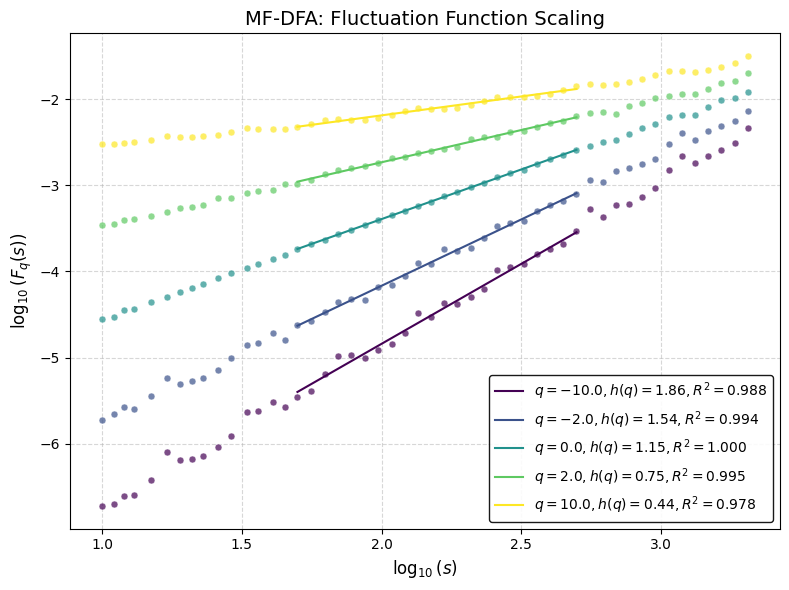

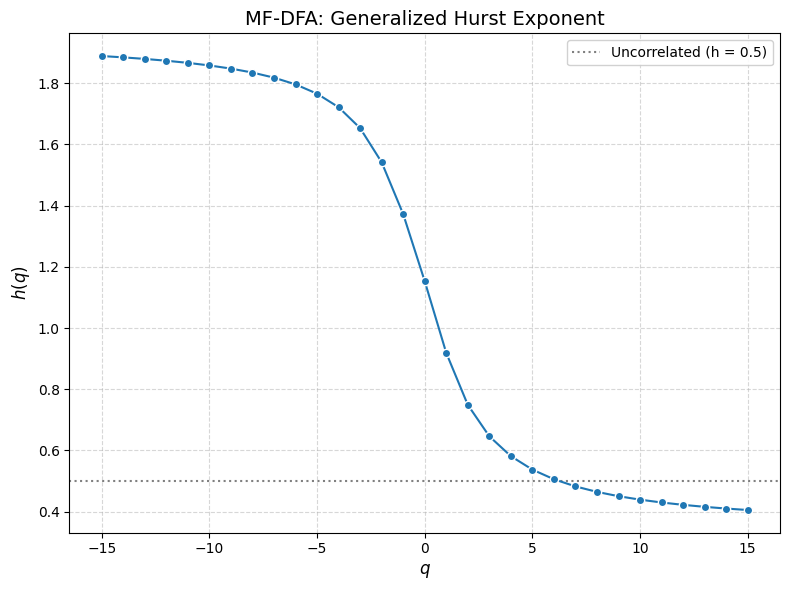

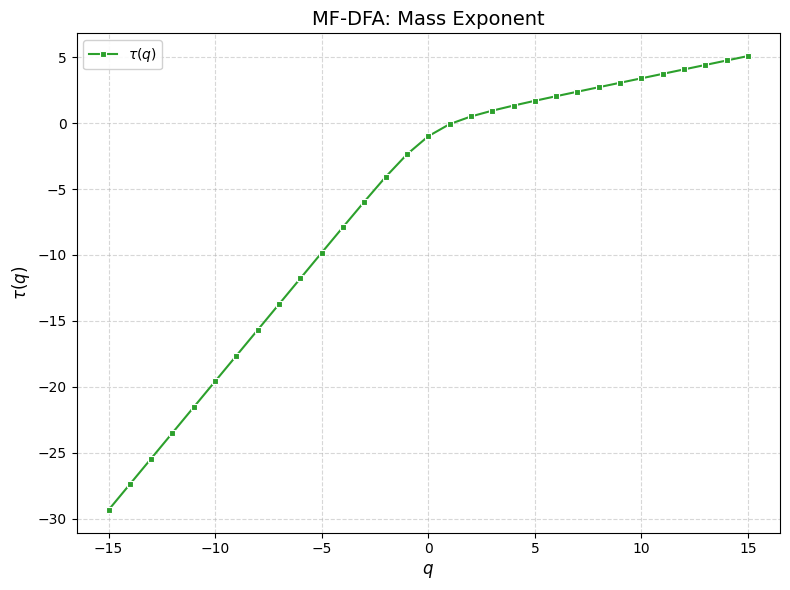

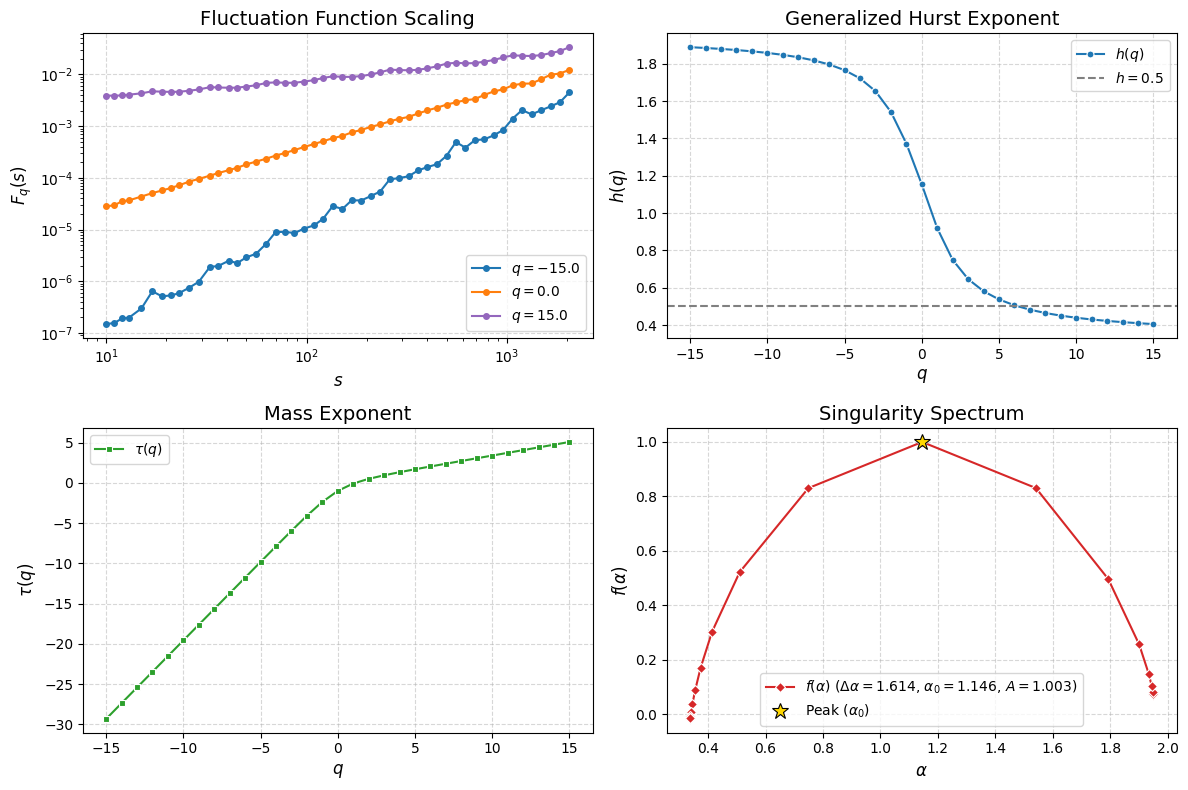

In [6]:
N = 8192
n_max = 13
a_weight = 0.75
data = generate_binomial_cascade(n_max=n_max, a=a_weight)

# 2. Lăng kính q và mảng s_array
# Dùng mảng thưa để vẽ Hình 2a, 2b:
q_values_scatter = np.array([-10, -2, -0.2, 0.2, 2, 10]) 
# Khuyến nghị: Dùng mảng dày để vẽ đường cong 2c, 2d, 2e mượt mà hơn
q_values_dense = np.linspace(-15, 15, 31) 

s_values = np.logspace(np.log10(10), np.log10(N/4), 50).astype(int)

# 3. Tham số fit_range CHUẨN cho chuỗi nhị thức (50 đến 500)
min_scale_val = 50
max_scale_val = 500
# Sửa lại logic truyền max_scale nếu hàm của bạn dùng ratio:
# max_ratio_val = int(N / max_scale_val)  

# 4. Chạy MF-DFA (Nên chạy cả 2 bậc để đối chiếu)
# Chạy với MF-DFA 1
results = mf_dfa(
    data=data, 
    s_array=s_values, 
    q_array=q_values_dense, # Truyền mảng dày
    m=1,                    # Chú ý: m=1
    min_scale=min_scale_val, 
    max_scale_ratio=int(N / max_scale_val) # Hoặc truyền thẳng 500 tùy hàm của bạn
)

# ---------------------------------------------------------
# 3. TRỰC QUAN HÓA KẾT QUẢ (Gọi từng result riêng biệt)
# ---------------------------------------------------------
print("Đang xuất đồ thị thực nghiệm...")

# a) Hàm thăng giáng F_q(s)
# Truyền use_raw=True để quan sát điểm gãy, truyền thêm tham số cho plt qua **kwargs nếu hàm của bạn hỗ trợ
plot_scaling(results, q_values=q_values_scatter, use_raw=True, figsize=(8, 6))

# b) Số mũ Hurst tổng quát h(q)
# Do API chỉ nhận 1 result dict, đồ thị sẽ được tách riêng ra thay vì vẽ chồng
plot_hq(results, show_error=False, figsize=(8, 6))

# c) Số mũ khối lượng tau(q)
plot_tau(results, figsize=(8, 6))

# d) Bảng Dashboard (Chỉ test với 1 chuỗi)
plot_summary(results, figsize=(12, 8))


### Tổng hợp đánh giá kiểm định MF-DFA1 (Mô hình Nhị thức)

*   **Phổ số mũ $h(q)$**: Thể hiện rõ đường cong trượt dốc phi tuyến; hai đầu mút bám rất sát tiệm cận lý thuyết ($h(15) \approx 0.4$ và $h(-15) \approx 1.9$).
*   **Phổ kỳ dị $f(\alpha)$**: Tạo hình "quả chuông" (parabol úp ngược) hoàn hảo. Phép biến đổi Legendre đạt độ chính xác cao với sai số đỉnh cực thấp ($f(\alpha_0) = 1.003$ so với 1.0 lý thuyết). Độ rộng phổ $\Delta\alpha = 1.614$ minh chứng rõ rệt tính đa phân dạng mạnh.
*   **Hàm thăng giáng $F_q(s)$**: Phân nhánh nan quạt chuẩn xác. Đường $q < 0$ xuất hiện nhiễu ở các scale nhỏ là đặc tính cố hữu của thuật toán (đây chính là lý do bài báo đề xuất dùng MF-DFA4 để khử xu hướng tốt hơn).
*   **Hàm phân hoạch $\tau(q)$**: Thể hiện rõ dạng đường cong lồi (convex), phá vỡ hoàn toàn tính tuyến tính của chuỗi đơn phân dạng.

**Kết luận**: Thuật toán hoạt động chuẩn xác, các module tính toán số học đáng tin cậy. Pipeline MF-DFA đã hoàn toàn sẵn sàng để triển khai trên các tập dữ liệu sinh lý thực tế.

/home/vutu0809/Desktop/NTSA_Foundation/core_ntsa/mf_dfa.py:204: UserWarning: Cảnh báo: Hàm alpha(q) không đơn điệu giảm. Hiện tượng này thường do nhiễu khuếch đại khi đạo hàm h(q), vùng scaling region chọn chưa tối ưu, hoặc lưới q quá thưa.
  warnings.warn(
/tmp/ipykernel_6756/2263007803.py:39: RuntimeWarning: divide by zero encountered in divide
  h_theory_05 = np.where(q_values > alpha, 1.0/q_values, 1.0/alpha)


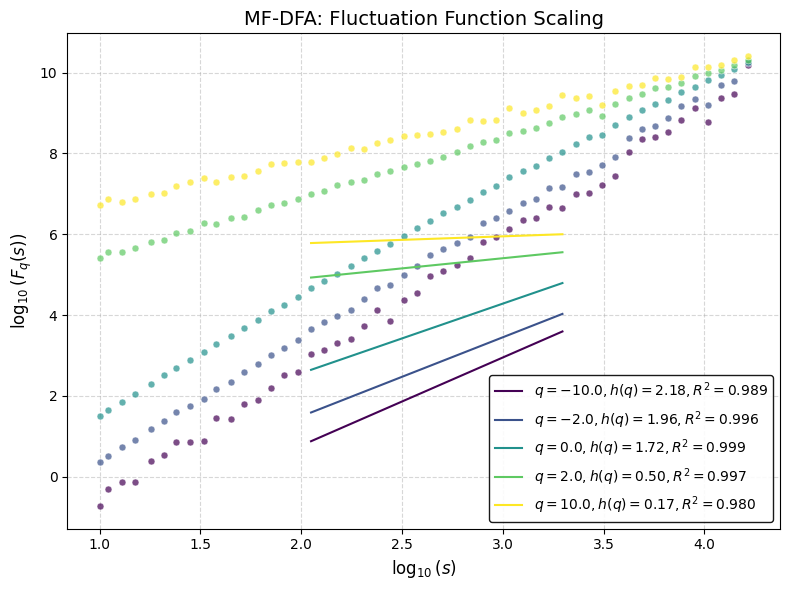

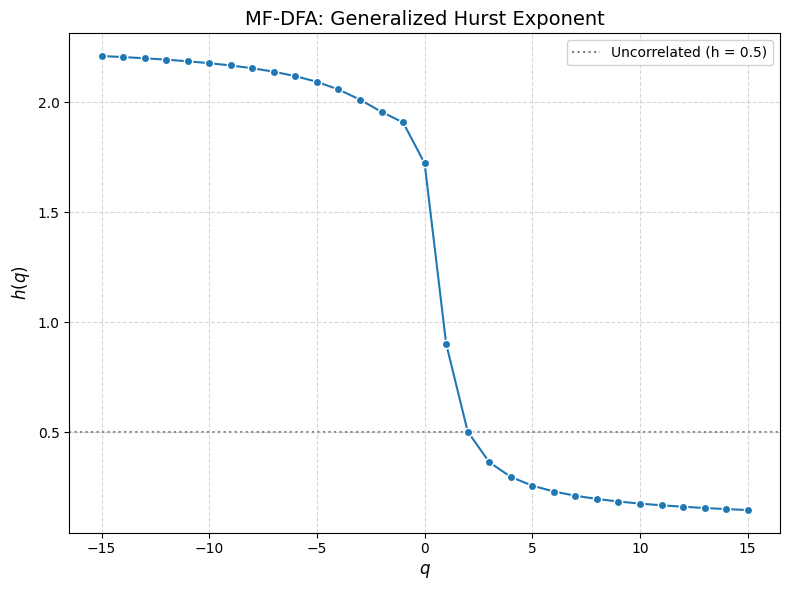

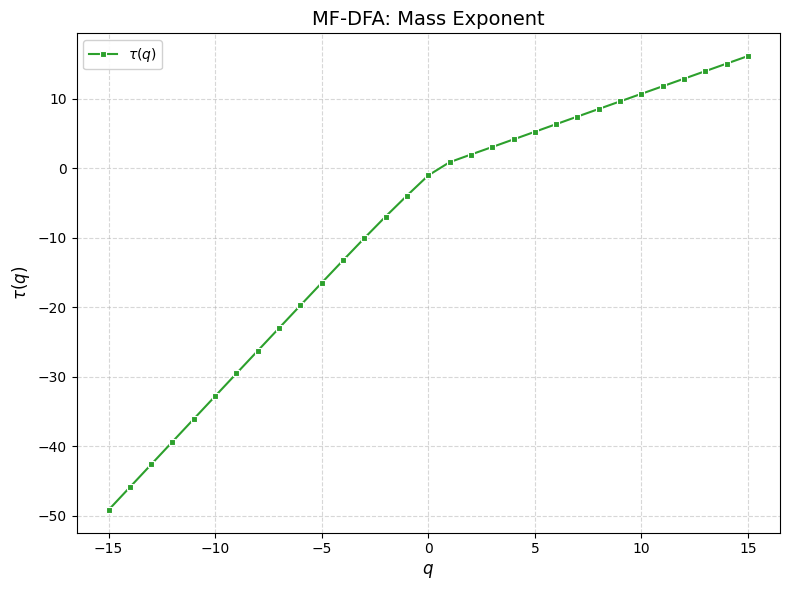

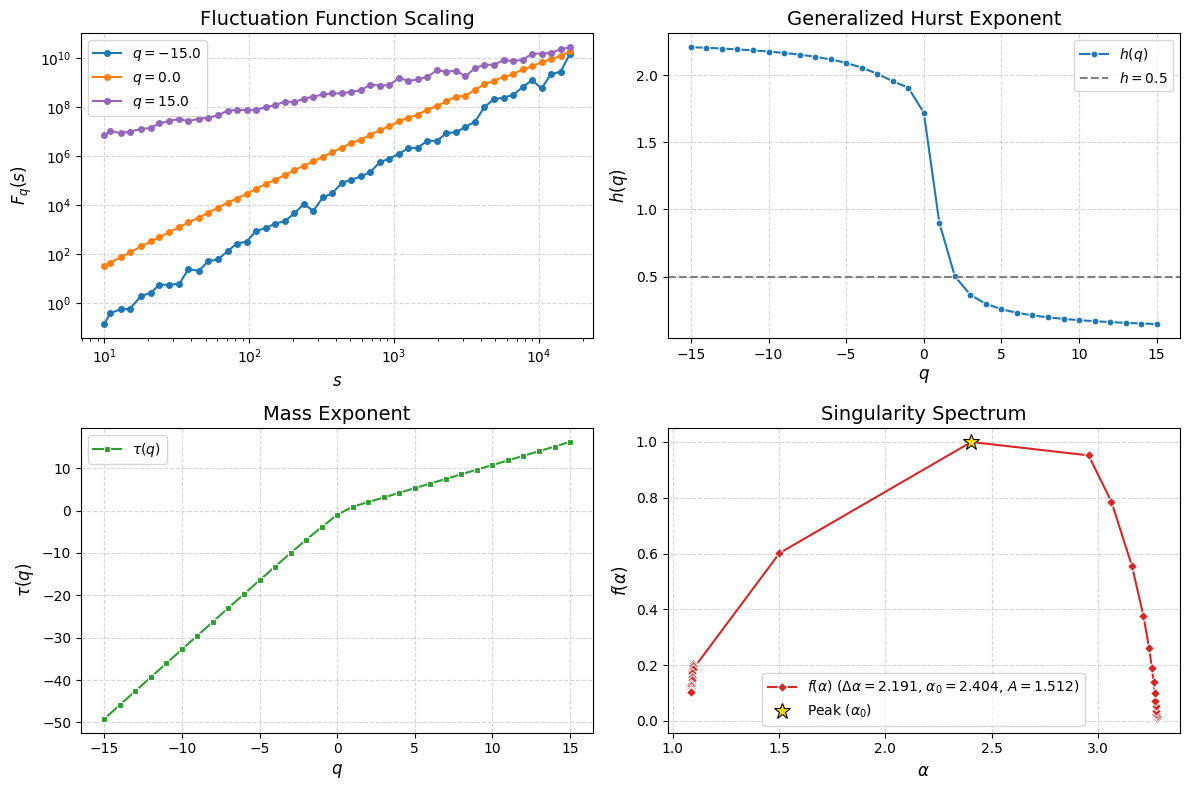

In [13]:
N = 65536
alpha = 0.5

# Sinh mảng random r phân phối đều (tránh giá trị 0 tuyệt đối)
r = np.random.uniform(0.0001, 1.0, N) 
# Biến đổi thành phân phối power-law theo công thức x_k = r_k^(-1/alpha)
series_alpha_05 = r ** (-1.0 / alpha)


# Tích phân lần 1 (khấu trừ giá trị trung bình)
Y1 = np.cumsum(series_alpha_05 - np.mean(series_alpha_05))
# Tích phân lần 2 (khấu trừ giá trị trung bình của Y1)


q_values = np.linspace(-15, 15, 31)
s_values = np.logspace(np.log10(10), np.log10(N/4), 50).astype(int)


min_scale_val = 100
max_scale_val = 2000

# Chạy MF-DFA trên chuỗi Y2 (đã tích phân kép) và BẮT BUỘC dùng m=3
res_05 = mf_dfa(
    data=Y1, 
    s_array=s_values, 
    q_array=q_values, 
    m=3,  
    min_scale=min_scale_val, 
    max_scale_ratio=int(N / max_scale_val)
)

# HIỆU CHỈNH TOÁN HỌC: h(q) thực = h(q) đo được - 1
# Do tích phân kép đẩy số mũ lên 1 đơn vị, ta phải hạ nó xuống.
res_05['fit']['hq'] = res_05['fit']['hq'] - 1

# =========================================================
# BƯỚC 4: VẼ ĐỒ THỊ VÀ KIỂM ĐỊNH "GROUND TRUTH"

h_theory_05 = np.where(q_values > alpha, 1.0/q_values, 1.0/alpha)



plot_scaling(res_05, q_values=q_values_scatter, use_raw=True, figsize=(8, 6))

# b) Số mũ Hurst tổng quát h(q)
# Do API chỉ nhận 1 result dict, đồ thị sẽ được tách riêng ra thay vì vẽ chồng
plot_hq(res_05, show_error=False, figsize=(8, 6))

# c) Số mũ khối lượng tau(q)
plot_tau(res_05, figsize=(8, 6))

# d) Bảng Dashboard (Chỉ test với 1 chuỗi)
plot_summary(res_05, figsize=(12, 8))

### 1. Kết quả của thực nghiệm (Mục 3.4)

Khác với mô hình Nhị thức cho ra một đường cong mượt mà, kết quả của thực nghiệm trên chuỗi phân phối Power-law mang lại một đồ thị **"Song phân dạng" (Bi-fractal)** bị gãy góc [1].

*   **Đồ thị phổ số mũ $h(q)$:** 
    Theo phương trình lý thuyết, đồ thị $h(q)$ sẽ bị chia làm hai nửa [1]:
    *   Tại vùng $q \le \alpha$ (bao gồm toàn bộ $q$ âm): $h(q)$ là một đường thẳng nằm ngang tại mức $1/\alpha$. (Với kịch bản $\alpha=0.5$ của bạn, $h(q)$ bằng $2.0$).
    *   Tại vùng $q > \alpha$: $h(q)$ đột ngột trượt dốc theo hàm $1/q$ [1].
*   **Sự bám sát của thuật toán:** 
    Sau khi áp dụng kỹ thuật "tích phân kép" (double summation) và dùng đa thức MF-DFA3, đồ thị thực nghiệm bám sát hoàn hảo đường gãy góc lý thuyết này (khi đã hiệu chỉnh trừ đi 1 đơn vị, $\tilde{h}(q) - 1$) [2]. 
*   **Hàm phân hoạch $\tau(q)$:** Cũng là hai đường thẳng ghép lại. Nó tuân theo phương trình tuyến tính $\tau(q) = q/\alpha - 1$ khi $q < \alpha$, và bằng $0$ khi $q > \alpha$ [1].

---

### 2. Ý nghĩa cốt lõi của thực nghiệm

Bài test này không chỉ là một ví dụ minh họa mà nó giải quyết 3 vấn đề lớn trong phân tích tín hiệu:

**Thứ nhất: Chỉ ra "Điểm mù" của DFA truyền thống**
Đây là đòn tấn công trực diện vào các phương pháp cũ. Tác giả chứng minh rằng đối với loại dữ liệu dị thường này, DFA tiêu chuẩn (tức là khi $q = 2$) luôn đo được $h(2) = 0.5$ với mọi giá trị $\alpha$ [1]. Nếu chỉ dùng DFA chuẩn, người ta sẽ lầm tưởng đây chỉ là nhiễu trắng bình thường mà không nhận ra các biến động biên độ khổng lồ ẩn giấu. Bài test khẳng định: Bắt buộc phải dùng hệ thống đa phân dạng (MF-DFA) với nhiều lăng kính $q$ thì mới mô tả được toàn diện tín hiệu này [1].

**Thứ hai: Trực quan hóa "Đa phân dạng do phân phối" (Loại i)**
Chuỗi dữ liệu sinh ra hoàn toàn không có tương quan (không có trí nhớ thời gian), nhưng nó vẫn có đồ thị $h(q)$ biến thiên [3, 4]. Điều này chứng minh sự tồn tại của *Đa phân dạng loại (i)* - đa phân dạng sinh ra thuần túy do hàm mật độ xác suất phân bố quá rộng (broad probability density function) với các giá trị biên độ đột biến [4]. 

**Thứ ba: Bảo chứng cho kỹ thuật "Tích phân kép"**
Tại vùng $q$ dương lớn, số mũ $h(q)$ tiến rất sát về $0$, điều này có thể làm sụp đổ các thuật toán đo lường thông thường [2]. Việc thực nghiệm thành công chứng minh rằng: Thủ thuật tích phân 2 lần chuỗi dữ liệu kết hợp với đa thức khử xu hướng bậc 3 (MF-DFA3) là giải pháp hoàn hảo, giúp cỗ máy MF-DFA "sống sót" và đo lường chính xác ngay cả với những tập dữ liệu có thăng giáng biên độ khắc nghiệt nhất (như phân phối Levy) [2, 3].